# M4: Smooth-transition VAR (STVAR) with VIX regime

The linear models in M2/M3 pool one set of coefficients across calm and
stress periods. The paper's hypothesis — soft data matters *more in hard
times* — is fundamentally about regime-dependent dynamics, which a linear
model cannot represent. The STVAR lets the dynamics shift smoothly
between a low-stress and a high-stress regime as a logistic function of
the VIX.

**Model** (`models/stvar.py`):
$$ y_t = [W_t,\; G(z_{t-1})\,W_t]\,B + \delta D_t + \varepsilon_t,\qquad G(z)=\frac{1}{1+e^{-\gamma(z-c)}} $$
with $W_t=[1,y_{t-1},\dots,y_{t-p}]$, $z$ the standardized VIX (exogenous,
lagged), and $D_t$ the COVID dummy.

Two design choices learned the hard way:
- **VIX is exogenous.** Putting it in the endogenous block makes the
  system forecast VIX, which feeds back into the regime weight and the
  iteration diverges.
- **Frozen-regime forecasting.** Future VIX is unknown, so the regime
  weight is held at its origin value $G(z_T)$ across the horizon
  (Auerbach--Gorodnichenko convention). A forecast made in a high-VIX
  month therefore uses high-stress dynamics throughout.

Inputs load from disk; no FRED calls.

In [1]:
import warnings
warnings.simplefilter('ignore')

import sys, pickle
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from load_config import load_config
from evaluation.feature_frame import build_feature_frame
from evaluation.gw import gw_test
from models.stvar import STVAR

ROOT = Path.cwd().parent
cfg = load_config(str(ROOT / 'configs/us.yaml'), secrets_path=str(ROOT / 'config.yaml'))
with open(ROOT / 'data/cache/inputs.pkl', 'rb') as f:
    d = pickle.load(f)
cubes, static = d['cubes'], d['static']

vix_m = static['VIXCLS'].copy(); vix_m.index = pd.to_datetime(vix_m.index)
vix_m = vix_m.resample('MS').mean()

BANDS = [(pd.Timestamp('2001-03-01'), pd.Timestamp('2001-11-01')),
         (pd.Timestamp('2007-12-01'), pd.Timestamp('2009-06-01')),
         (pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'))]

## 1. The transition function

Fit the STVAR on the full long-window sample and plot the regime weight
$G(z_{t-1})$ over time, alongside the VIX. $G\to1$ marks the high-stress
regime.

STVAR(p=4, n_endog=6, gamma=12.0, c=2.0, G_origin=0.000)


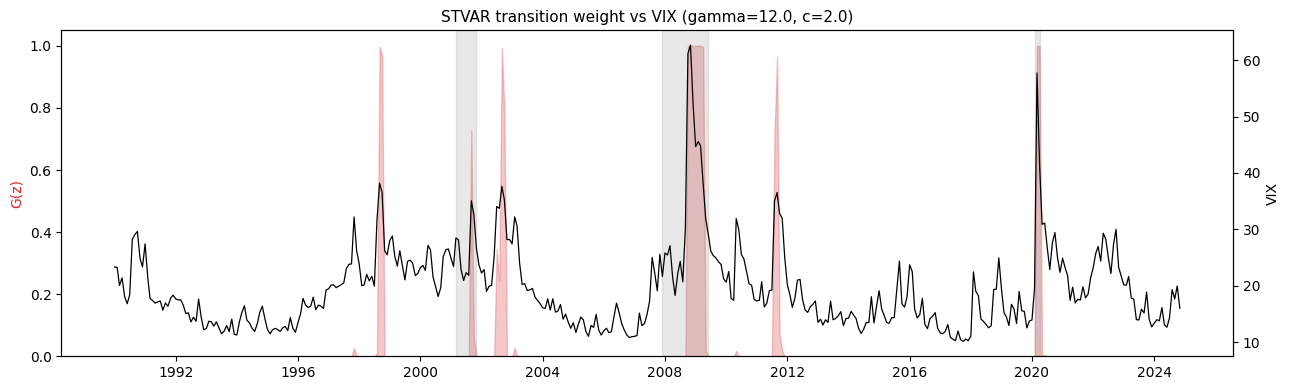

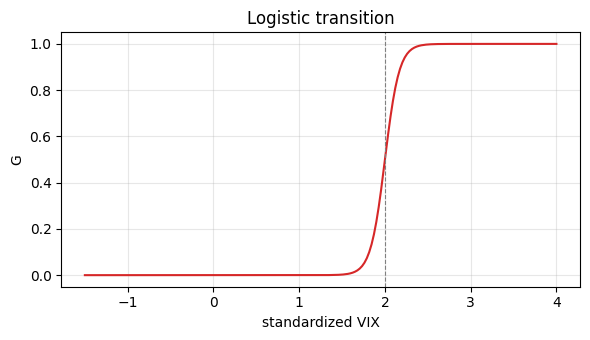

In [2]:
HARD = ['unemployment','industrial_production','payrolls','core_pce','ffr','gs10']
VARS = HARD + ['vix']
full = build_feature_frame(cfg, cubes, static, pd.Timestamp('2025-01-01'), variables=VARS).dropna(how='any')
m = STVAR(lags=4, transition_var='vix').fit(full, list(full.columns))
print(m)
G = m.transition_weights(full)

fig, ax1 = plt.subplots(figsize=(13, 4))
ax1.fill_between(G.index, G.values, 0, color='#d62728', alpha=0.25, label='G (high-stress weight)')
ax1.set_ylabel('G(z)', color='#d62728'); ax1.set_ylim(0, 1.05)
for s_, e_ in BANDS: ax1.axvspan(s_, e_, color='grey', alpha=0.18)
ax2 = ax1.twinx()
ax2.plot(vix_m.reindex(G.index).index, vix_m.reindex(G.index).values, color='black', lw=0.9, label='VIX')
ax2.set_ylabel('VIX')
ax1.set_title(f'STVAR transition weight vs VIX (gamma={m.gamma_}, c={m.c_})', fontsize=11)
plt.tight_layout(); plt.show()

# The logistic curve itself
zz = np.linspace(-1.5, 4, 200)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(zz, 1/(1+np.exp(-m.gamma_*(zz-m.c_))), color='#d62728')
ax.axvline(m.c_, color='grey', ls='--', lw=0.8)
ax.set_xlabel('standardized VIX'); ax.set_ylabel('G'); ax.set_title('Logistic transition'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 2. STVAR vs COVID-dummy VAR (hard-only)

Does letting dynamics shift with the regime improve the hard-only
forecast at all? Compare long-window RMSE.

In [3]:
dummy_long = pd.read_parquet(ROOT / 'data/forecasts/long_window_covid_dummy.parquet')
stvar_long = pd.read_parquet(ROOT / 'data/forecasts/long_window_stvar.parquet')

def rmse(res, spec):
    s = res[res.spec==spec].dropna(subset=['error']).copy(); s['se']=s['error']**2
    return s.groupby(['target','horizon'])['se'].mean().pow(0.5)

cmp = pd.DataFrame({'dummy_VAR': rmse(dummy_long,'hard_only'),
                    'STVAR':     rmse(stvar_long,'hard_only')})
cmp['STVAR_better_%'] = 100*(cmp['dummy_VAR']-cmp['STVAR'])/cmp['dummy_VAR']
print(cmp.round(3).to_string())

                               dummy_VAR  STVAR  STVAR_better_%
target                horizon                                  
core_pce              1            0.595  0.630          -5.862
                      3            0.755  0.768          -1.702
                      6            0.929  0.954          -2.720
                      12           1.235  1.226           0.740
industrial_production 1            2.778  2.256          18.779
                      3            5.408  3.806          29.616
                      6            7.043  4.836          31.336
                      12           8.126  6.291          22.581
payrolls              1            1.455  1.379           5.201
                      3            2.602  2.384           8.367
                      6            3.628  2.918          19.573
                      12           5.416  3.137          42.088
unemployment          1            0.845  0.743          12.054
                      3            1.661

## 3. The headline test: soft vs hard, conditional on the regime

Within the STVAR, compare hard vs hard+soft and run the
Giacomini--White test. The conditional-on-VIX p-value is the paper's
central statistic: is the soft-vs-hard loss differential predictable
from the stress regime?

In [4]:
stvar_short = pd.read_parquet(ROOT / 'data/forecasts/short_window_stvar.parquet')
TARGETS = ['unemployment','industrial_production','payrolls','core_pce']
HORIZONS = [1,3,6,12]

def gw_panel(res, soft_spec):
    rows = []
    for tgt in TARGETS:
        for h in HORIZONS:
            hard = res[(res.target==tgt)&(res.horizon==h)&(res.spec=='hard_only')].set_index('origin')
            soft = res[(res.target==tgt)&(res.horizon==h)&(res.spec==soft_spec)].set_index('origin')
            idx = hard.index.intersection(soft.index)
            l1=(hard.loc[idx,'error']**2); l2=(soft.loc[idx,'error']**2); vx=vix_m.reindex(idx)
            ok=l1.notna()&l2.notna()&vx.notna(); l1,l2,vx=l1[ok].values,l2[ok].values,vx[ok].values
            if len(l1)<20: continue
            u=gw_test(l1,l2,tau=h,choice='uncond'); c=gw_test(l1,l2,tau=h,choice='cond',instruments=vx)
            rows.append({'target':tgt,'horizon':h,'n':len(l1),
                         'soft_imp_%':100*(np.sqrt(l1.mean())-np.sqrt(l2.mean()))/np.sqrt(l1.mean()),
                         'DM_p':u.pval,'GW_vix_p':c.pval,'better':'soft' if u.better_model==2 else 'hard'})
    return pd.DataFrame(rows)

print('=== STVAR long: hard vs hard+UMCSENT ===')
print(gw_panel(stvar_long,'hard_plus_umcsent').round(4).to_string(index=False))
print('\n=== STVAR short: hard vs hard+soft factor ===')
print(gw_panel(stvar_short,'hard_plus_soft_factor').round(4).to_string(index=False))

=== STVAR long: hard vs hard+UMCSENT ===
               target  horizon   n  soft_imp_%   DM_p  GW_vix_p better
         unemployment        1 262      4.2141 0.4777    0.7754   soft
         unemployment        3 262     -1.2321 0.1291    0.3068   hard
         unemployment        6 262     -0.1666 0.7956    0.7932   hard
         unemployment       12 261      0.1831 0.8650    0.4757   soft
industrial_production        1 262     -2.4273 0.1302    0.2676   hard
industrial_production        3 262     -9.8334 0.1204    0.2630   hard
industrial_production        6 262     -7.9822 0.1733    0.3931   hard
industrial_production       12 262      7.2174 0.2887    0.5610   soft
             payrolls        1 262      0.9490 0.5586    0.2336   soft
             payrolls        3 262     -1.2129 0.0645    0.1298   hard
             payrolls        6 262     -2.1536 0.0596    0.0624   hard
             payrolls       12 262      1.2924 0.9867    0.9934   soft
             core_pce        1 262  

## 4. RMSE by VIX regime — the visual answer

Bin forecast origins by their VIX level and compare hard vs hard+soft
RMSE within each bin. If the hypothesis holds, the soft advantage should
widen in the high-VIX bins.

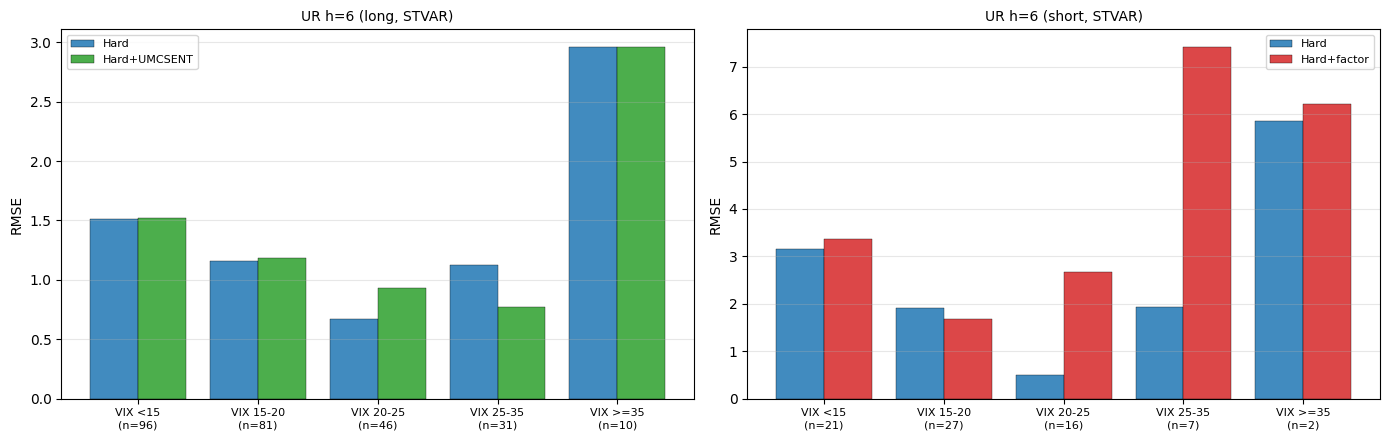

In [5]:
def rmse_by_bin(res, target, horizon, specs):
    m = res[res.ok].copy().merge(vix_m.rename('vx'), left_on='origin', right_index=True, how='left')
    m['bin'] = pd.cut(m['vx'], [0,15,20,25,35,200], labels=['<15','15-20','20-25','25-35','>=35'])
    sub = m[(m.target==target)&(m.horizon==horizon)].copy(); sub['se']=sub['error']**2
    tab = sub.groupby(['bin','spec'],observed=True)['se'].mean().pow(0.5).unstack('spec')
    n = sub.groupby('bin',observed=True).size()//sub.spec.nunique()
    return tab[[s for s in specs if s in tab.columns]], n

COL = {'hard_only':'#1f77b4','hard_plus_umcsent':'#2ca02c','hard_plus_soft_factor':'#d62728'}
LAB = {'hard_only':'Hard','hard_plus_umcsent':'Hard+UMCSENT','hard_plus_soft_factor':'Hard+factor'}

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax,(tgt,specs,res,title) in zip(axes,[
    ('unemployment',['hard_only','hard_plus_umcsent'],stvar_long,'UR h=6 (long, STVAR)'),
    ('unemployment',['hard_only','hard_plus_soft_factor'],stvar_short,'UR h=6 (short, STVAR)')]):
    tab,n = rmse_by_bin(res,tgt,6,specs)
    x=np.arange(len(tab)); bw=0.8/len(specs)
    for si,sp in enumerate(specs):
        ax.bar(x+(si-(len(specs)-1)/2)*bw, tab[sp].values, bw, color=COL[sp], alpha=0.85, label=LAB[sp], edgecolor='black', linewidth=0.3)
    ax.set_xticks(x); ax.set_xticklabels([f'VIX {b}\n(n={int(n.loc[b])})' for b in tab.index], fontsize=8)
    ax.set_ylabel('RMSE'); ax.set_title(title, fontsize=10); ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)
plt.tight_layout(); plt.show()

## Takeaways

These results use the **numerically safeguarded** STVAR: candidate $(\gamma,c)$ combinations are accepted only if (i) the effective companion matrix at the origin regime weight is stationary (spectral radius < 1, after shrinking the data-poor high-stress block) and (ii) the forecast keeps the federal funds rate $\ge 0$ over the horizon. Origins where no combination qualifies are dropped (`ok=False`) — 18/288 long-window origins, concentrated in the deep-ZLB months of 2009 and 2020. After these screens, the maximum absolute forecast across all origins is ~29 (long) / ~58 (short), all at COVID-period origins; no explosions.

**Two findings, and they cut against the original hypothesis.**

**1. The regime-switching model substantially improves *hard-data* forecasts.** Relative to the COVID-dummy linear VAR, the STVAR (hard-only) cuts RMSE by:
- Unemployment: **12% (h=1) → 62% (h=12)**
- Industrial production: **19% → 31%**
- Payrolls: **5% → 42%**

Letting the hard-data dynamics shift with the VIX regime is, by itself, a large gain — the linear and dummy VARs left this on the table.

**2. Once the model is regime-switching, adding soft data mostly does *not* help — and sometimes significantly hurts.**
- Long window, hard+UMCSENT: mixed and mostly insignificant; only core PCE leans soft (DM $p\approx0.08$ at $h=1$).
- Short window, hard+soft factor: the soft factor **significantly worsens** unemployment forecasts — DM $p = 0.029, 0.038, 0.037$ at $h=1,3,6$, all favoring hard-only.

**Interpretation (tentative).** The predictive value commonly attributed to "soft data in hard times" may be, at least in part, the value of *allowing hard-data dynamics to differ across regimes*. A nonlinear hard-data model appears to capture the crisis-period information that soft data was thought to supply; conditional on that, the surveys add little incremental signal. This is a coherent and arguably more interesting story than the one hypothesized — but it reverses the paper's premise, so it must be stated carefully.

**Caveats.**
- The short window has only $n=66$ usable origins after the screens; the significant negative soft-factor result rests on few crisis episodes and could reflect the PCA factor being noisy precisely at COVID-trough origins (where its inputs were extreme).
- The GW-conditional-on-VIX $p$-values are mostly insignificant, so we cannot claim the soft/hard ordering is *itself* regime-dependent in a statistically reliable way.
- COVID-origin forecasts are bounded but poor (e.g. IP $h=1$ forecast $-58\%$ vs realized $-16\%$); the RMSEs reflect genuine large misses at those origins, not artifacts.

**Next:** the cleanest robustness check on finding 2 is to (a) re-run without the COVID dummy so the regime absorbs both 2008 and 2020, and (b) compare against a Markov-switching specification, which imposes stationarity per regime by construction and needs no threshold variable.